### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [4]:
print(data.info())
#print(data.describe(include='all'))
with pd.option_context('display.max_columns', None, 'display.max_rows', None):
    print(data.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [5]:
#Using the code to get the unique count and values in each column of the dataset
for x in data.columns:
    print(x,"(", len(data[x].unique()), ") ", data[x].unique() )

destination ( 3 )  ['No Urgent Place' 'Home' 'Work']
passanger ( 4 )  ['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
weather ( 3 )  ['Sunny' 'Rainy' 'Snowy']
temperature ( 3 )  [55 80 30]
time ( 5 )  ['2PM' '10AM' '6PM' '7AM' '10PM']
coupon ( 5 )  ['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
expiration ( 2 )  ['1d' '2h']
gender ( 2 )  ['Female' 'Male']
age ( 8 )  ['21' '46' '26' '31' '41' '50plus' '36' 'below21']
maritalStatus ( 5 )  ['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
has_children ( 2 )  [1 0]
education ( 6 )  ['Some college - no degree' 'Bachelors degree' 'Associates degree'
 'High School Graduate' 'Graduate degree (Masters or Doctorate)'
 'Some High School']
occupation ( 25 )  ['Unemployed' 'Architecture & Engineering' 'Student'
 'Education&Training&Library' 'Healthcare Support'
 'Healthcare Practitioners & Technical' 'Sales & Related' 'Management'
 'Arts Design Entertainment Sports & Media' 'Computer & Mathematica

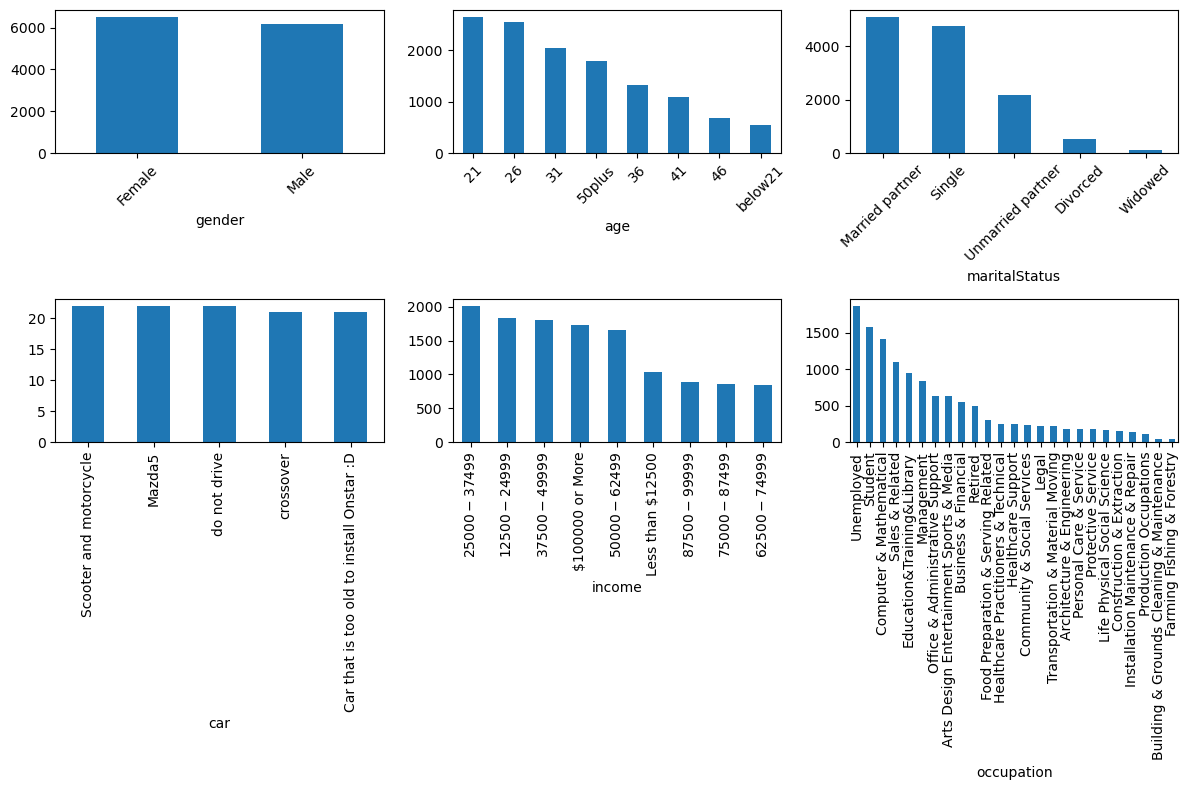

In [6]:
fig, axes = plt.subplots(nrows=2,ncols=3, figsize=(12, 8))
data.gender.value_counts().plot(kind='bar', ax = axes[0,0])
data.age.value_counts().plot(kind='bar', ax = axes[0,1])
data.maritalStatus.value_counts().plot(kind='bar', ax = axes[0,2])
for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=45, labelsize=10)
data.occupation.value_counts().plot(kind='bar')
data.car.value_counts().plot(kind='bar', ax = axes[1,0])
data.income.value_counts().plot(kind='bar', ax = axes[1,1])
plt.tight_layout()

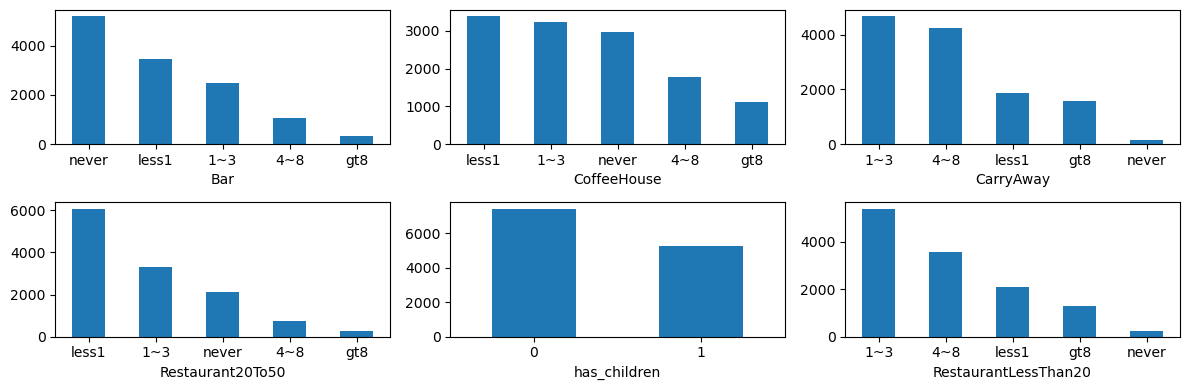

In [7]:
fig, axes = plt.subplots(nrows=2,ncols=3, figsize=(12, 4))
data.Bar.value_counts().plot(kind='bar', ax = axes[0,0])
data.CoffeeHouse.value_counts().plot(kind='bar', ax = axes[0,1])
data.CarryAway.value_counts().plot(kind='bar', ax = axes[0,2])
data.RestaurantLessThan20.value_counts().plot(kind='bar')
data.Restaurant20To50.value_counts().plot(kind='bar', ax = axes[1,0])
data.has_children.value_counts().plot(kind='bar', ax = axes[1,1])
for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=0, labelsize=10)
plt.tight_layout()

3. Decide what to do about your missing data -- drop, replace, other...

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64
        temperature  has_children  toCoupon_GEQ5min  toCoupon_GEQ15min  \
count  12684.000000  12684.000000           12684.0       12684.000000   
mean      63.301798      0.414144               1.0        

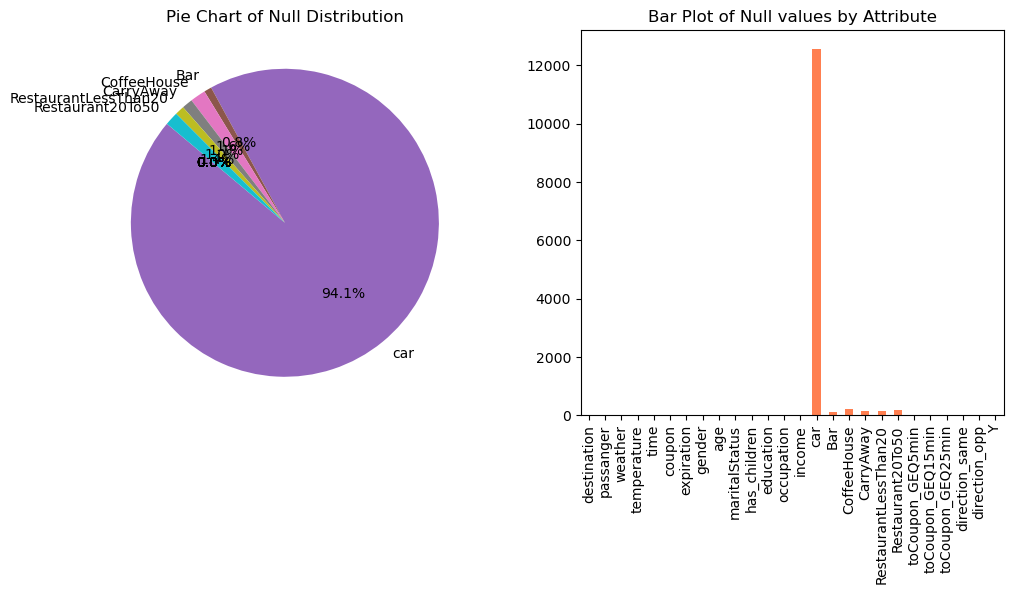

In [8]:
null_distribution = data.isna().sum()
plt.figure(figsize=(12,5))
plt.subplot(121)
null_distribution.plot(kind='pie', autopct='%1.1f%%', startangle=140, title='Pie Chart of Null Distribution')
plt.subplot(122)
null_distribution.plot.bar(color='coral', title='Bar Plot of Null values by Attribute')
print(data.isna().sum())
print(data.describe())
print(data.duplicated().value_counts())

As the 'car' column in the dataset has 94% null rows or above 12,000 rows empty, so, planning to drop the column 'car'.
The other columns are less than 0.1% empty or null, so planning to replace them with the mode or value with highest frequency for that column.  Also checking on the duplicates and dropping the duplicates that are close to 74 rows.

In [9]:
print("Duplicates\n", data.duplicated().value_counts())
data1=data.drop(columns='car')
for column in data1.columns:
    if data1[column].isnull().any():
        mode_val=data1[column].mode()[0]
        data1[column].fillna(value=mode_val, inplace=True)
data1[data1.duplicated()==True].index

data1=data1.drop_duplicates()
print("Orignal data shape", data.shape, ", Final data 'data1' shape", data1.shape)

Duplicates
 False    12610
True        74
Name: count, dtype: int64
Orignal data shape (12684, 26) , Final data 'data1' shape (12610, 25)


/var/folders/9f/n01h6dvx1z13fdfthpd1yhnm0000gn/T/ipykernel_51220/1043690606.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data1[column].fillna(value=mode_val, inplace=True)


4. What proportion of the total observations chose to accept the coupon?



In [10]:
print(f"Percentage of total observation to accept coupon: {data1.Y.value_counts()[1]/data1.shape[0]*100:,.2f}%")
data1.Y.value_counts(normalize = True)

Percentage of total observation to accept coupon: 56.76%


Y
1    0.567565
0    0.432435
Name: proportion, dtype: float64

5. Use a bar plot to visualize the `coupon` column.

                  coupon  Y  count
0                    Bar  0   1186
1                    Bar  1    824
2  Carry out & Take away  0    624
3  Carry out & Take away  1   1720
4           Coffee House  0   2000
5           Coffee House  1   1989
6      Restaurant(20-50)  0    831
7      Restaurant(20-50)  1    657
8        Restaurant(<20)  0    812
9        Restaurant(<20)  1   1967
  expiration  Y  count
0         1d  0   2641
1         1d  1   4390
2         2h  0   2812
3         2h  1   2767


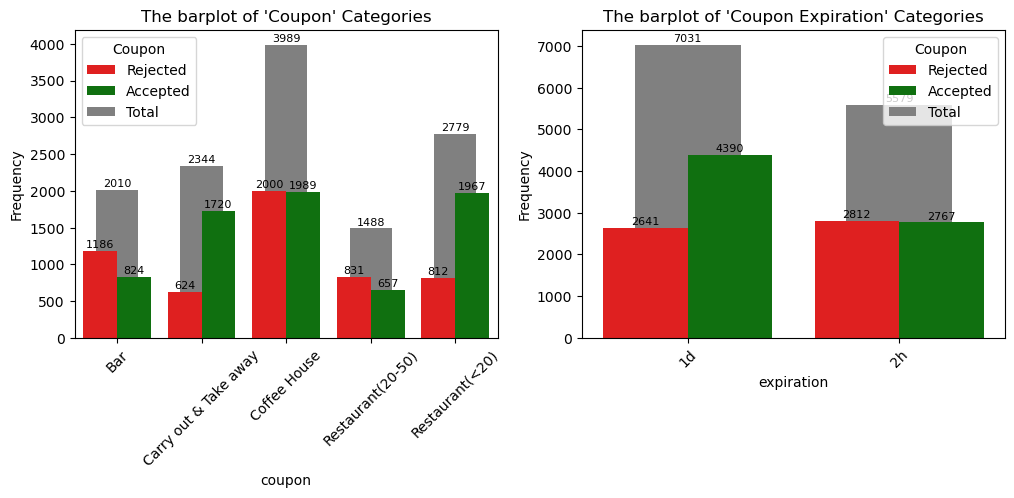

In [11]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))
custom_palette ={0: '#FF0000', 1: '#008000' }

fig1=data1.coupon.value_counts().sort_index().plot.bar(color='grey', ax = axes[0])
nobs=data1.groupby('coupon')['Y'].value_counts().sort_index().reset_index()
print(nobs)
ax = sns.barplot(data=nobs, x='coupon', y='count', hue='Y', palette=custom_palette, ax = axes[0])
ax.set_title("The barplot of 'Coupon' Categories")

data1.expiration.value_counts().sort_index().plot.bar(color='grey', ax = axes[1])
nobs=data1.groupby('expiration')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='expiration', y='count', hue='Y', palette=custom_palette, ax = axes[1])
print(nobs)
ax.set_title("The barplot of 'Coupon Expiration' Categories")

#ax.bar_label(ax.containers[0], label_type='center', color='white',fontsize=9)
for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.set_ylabel('Frequency')
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, ['Rejected', 'Accepted', 'Total'], title="Coupon")
    for container in ax.containers:
        ax.bar_label(container, fontsize=8, padding=1)

6. Use a histogram to visualize the temperature column.

Text(0.5, 1.0, 'The histogram of %Coupon Accept/Reject as a function of temperature')

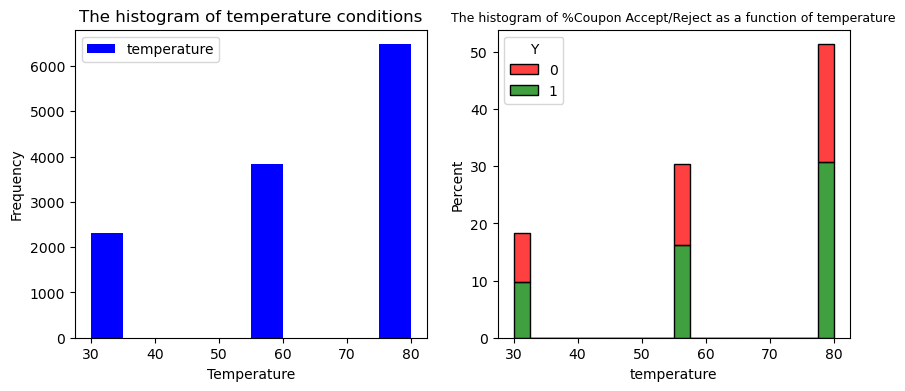

In [12]:
fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(10, 4))
data1.plot(kind='hist', y='temperature', color = ['b'], xlabel='Temperature', ax = axes[0], title='The histogram of temperature conditions')

ax=sns.histplot(data=data1, x='temperature', hue='Y', multiple='stack', bins=20, palette=custom_palette,stat='percent', ax=axes[1])
ax.set_title('The histogram of %Coupon Accept/Reject as a function of temperature', fontsize=9)



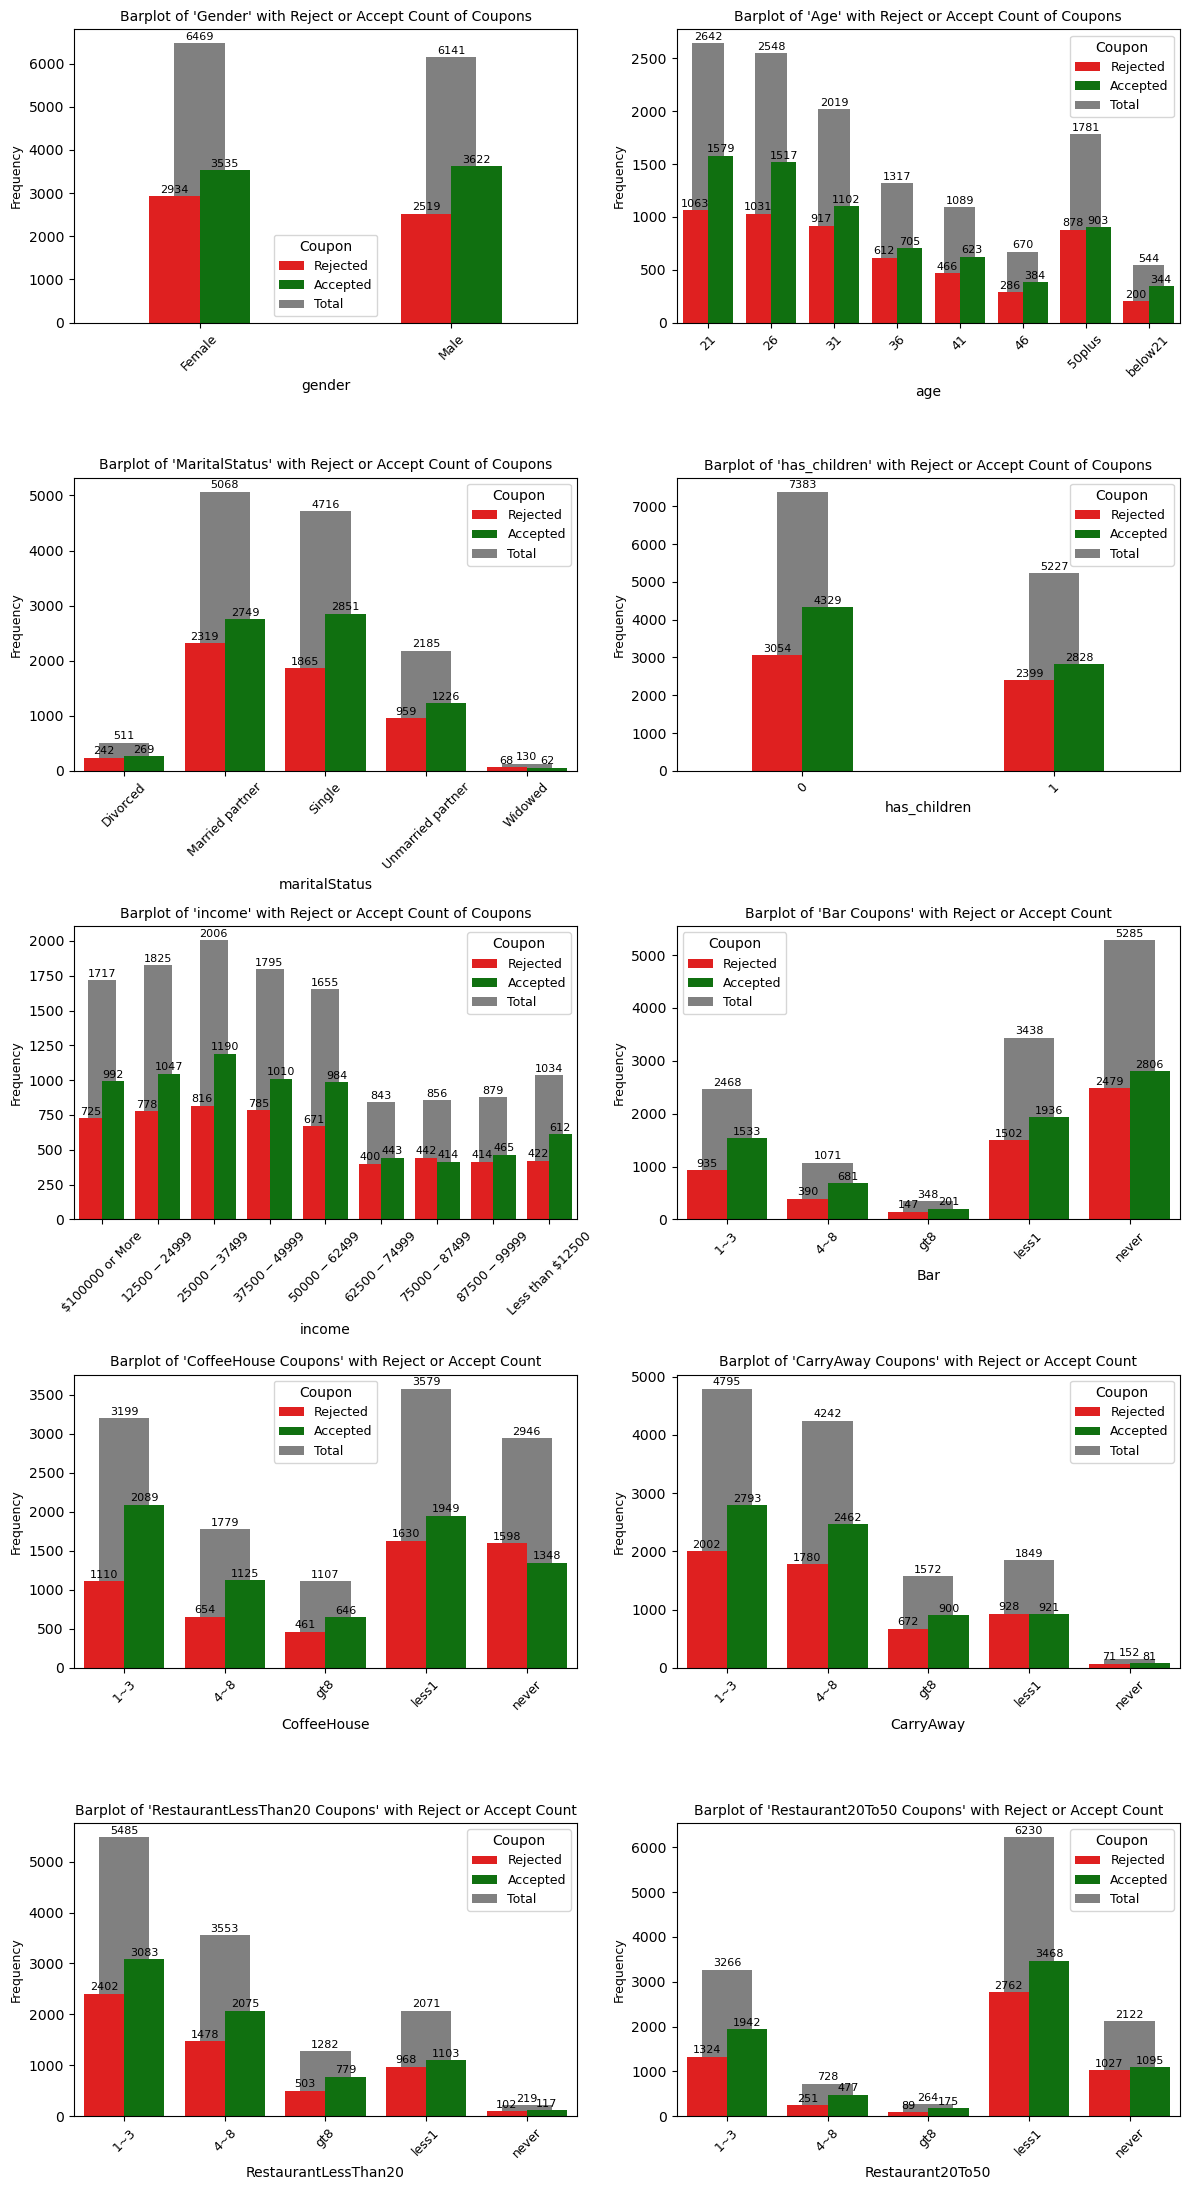

In [13]:
fig, axes = plt.subplots(nrows=5,ncols=2, figsize=(12, 22))

data1.gender.value_counts().sort_index().plot(kind='bar', color='grey',width = 0.2,ax = axes[0,0])
nobs=data1.groupby('gender')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='gender', y='count', hue='Y', palette=custom_palette,width = 0.4, ax = axes[0,0])
ax.set_title("Barplot of 'Gender' with Reject or Accept Count of Coupons", fontsize=10)

data1.age.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[0,1])
nobs=data1.groupby('age')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='age', y='count', hue='Y', palette=custom_palette, ax = axes[0,1])
ax.set_title("Barplot of 'Age' with Reject or Accept Count of Coupons", fontsize=10)

data1.maritalStatus.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[1,0])
nobs=data1.groupby('maritalStatus')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='maritalStatus', y='count', hue='Y', palette=custom_palette, ax = axes[1,0])
ax.set_title("Barplot of 'MaritalStatus' with Reject or Accept Count of Coupons", fontsize=10)
   
data1.has_children.value_counts().sort_index().plot(kind='bar', color='grey',width = 0.2,ax = axes[1,1])
nobs=data1.groupby('has_children')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='has_children', y='count', hue='Y', palette=custom_palette,width = 0.4, ax = axes[1,1])
ax.set_title("Barplot of 'has_children' with Reject or Accept Count of Coupons", fontsize=10)

data1.income.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[2,0])
nobs=data1.groupby('income')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='income', y='count', hue='Y', palette=custom_palette, ax = axes[2,0])
ax.set_title("Barplot of 'income' with Reject or Accept Count of Coupons", fontsize=10)

data1.Bar.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[2,1])
nobs=data1.groupby('Bar')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='Bar', y='count', hue='Y', palette=custom_palette, ax = axes[2,1])
ax.set_title("Barplot of 'Bar Coupons' with Reject or Accept Count", fontsize=10)

data1.CoffeeHouse.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[3,0])
nobs=data1.groupby('CoffeeHouse')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='CoffeeHouse', y='count', hue='Y', palette=custom_palette, ax = axes[3,0])
ax.set_title("Barplot of 'CoffeeHouse Coupons' with Reject or Accept Count", fontsize=10)

data1.CarryAway.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[3,1])
nobs=data1.groupby('CarryAway')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='CarryAway', y='count', hue='Y', palette=custom_palette, ax = axes[3,1])
ax.set_title("Barplot of 'CarryAway Coupons' with Reject or Accept Count", fontsize=10)

data1.RestaurantLessThan20.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[4,0])
nobs=data1.groupby('RestaurantLessThan20')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='RestaurantLessThan20', y='count', hue='Y', palette=custom_palette, ax = axes[4,0])
ax.set_title("Barplot of 'RestaurantLessThan20 Coupons' with Reject or Accept Count", fontsize=10)

data1.Restaurant20To50.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[4,1])
nobs=data1.groupby('Restaurant20To50')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='Restaurant20To50', y='count', hue='Y', palette=custom_palette, ax = axes[4,1])
ax.set_title("Barplot of 'Restaurant20To50 Coupons' with Reject or Accept Count", fontsize=10)

for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['Rejected', 'Accepted', 'Total'], title="Coupon", fontsize=9)
    for container in ax.containers:
        ax.bar_label(container, fontsize=8, padding=1)

plt.tight_layout()

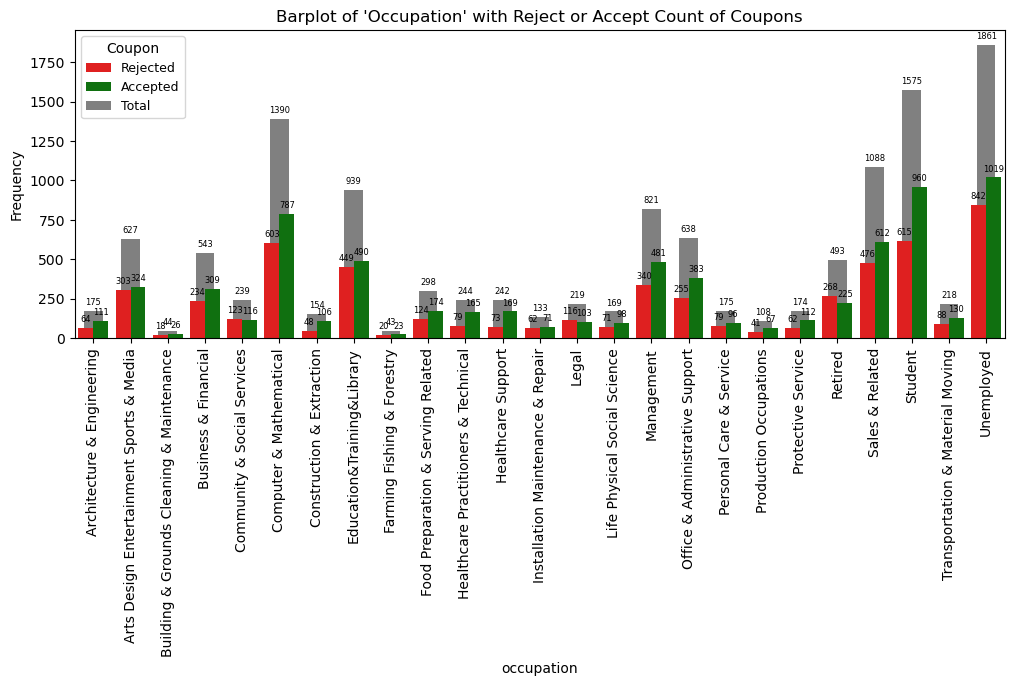

In [14]:
fig = plt.figure(figsize=(12, 4))
data1.occupation.value_counts().sort_index().plot(kind='bar', color='grey')
nobs=data1.groupby('occupation')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='occupation', y='count', hue='Y', palette=custom_palette)
ax.set_title("Barplot of 'Occupation' with Reject or Accept Count of Coupons", fontsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Rejected', 'Accepted', 'Total'], title="Coupon", fontsize=9)
plt.rcParams['axes.labelsize'] = 10  
for container in ax.containers:
    ax.bar_label(container, fontsize=6, padding=3)
    ax.set_ylabel('Frequency', fontsize=10)

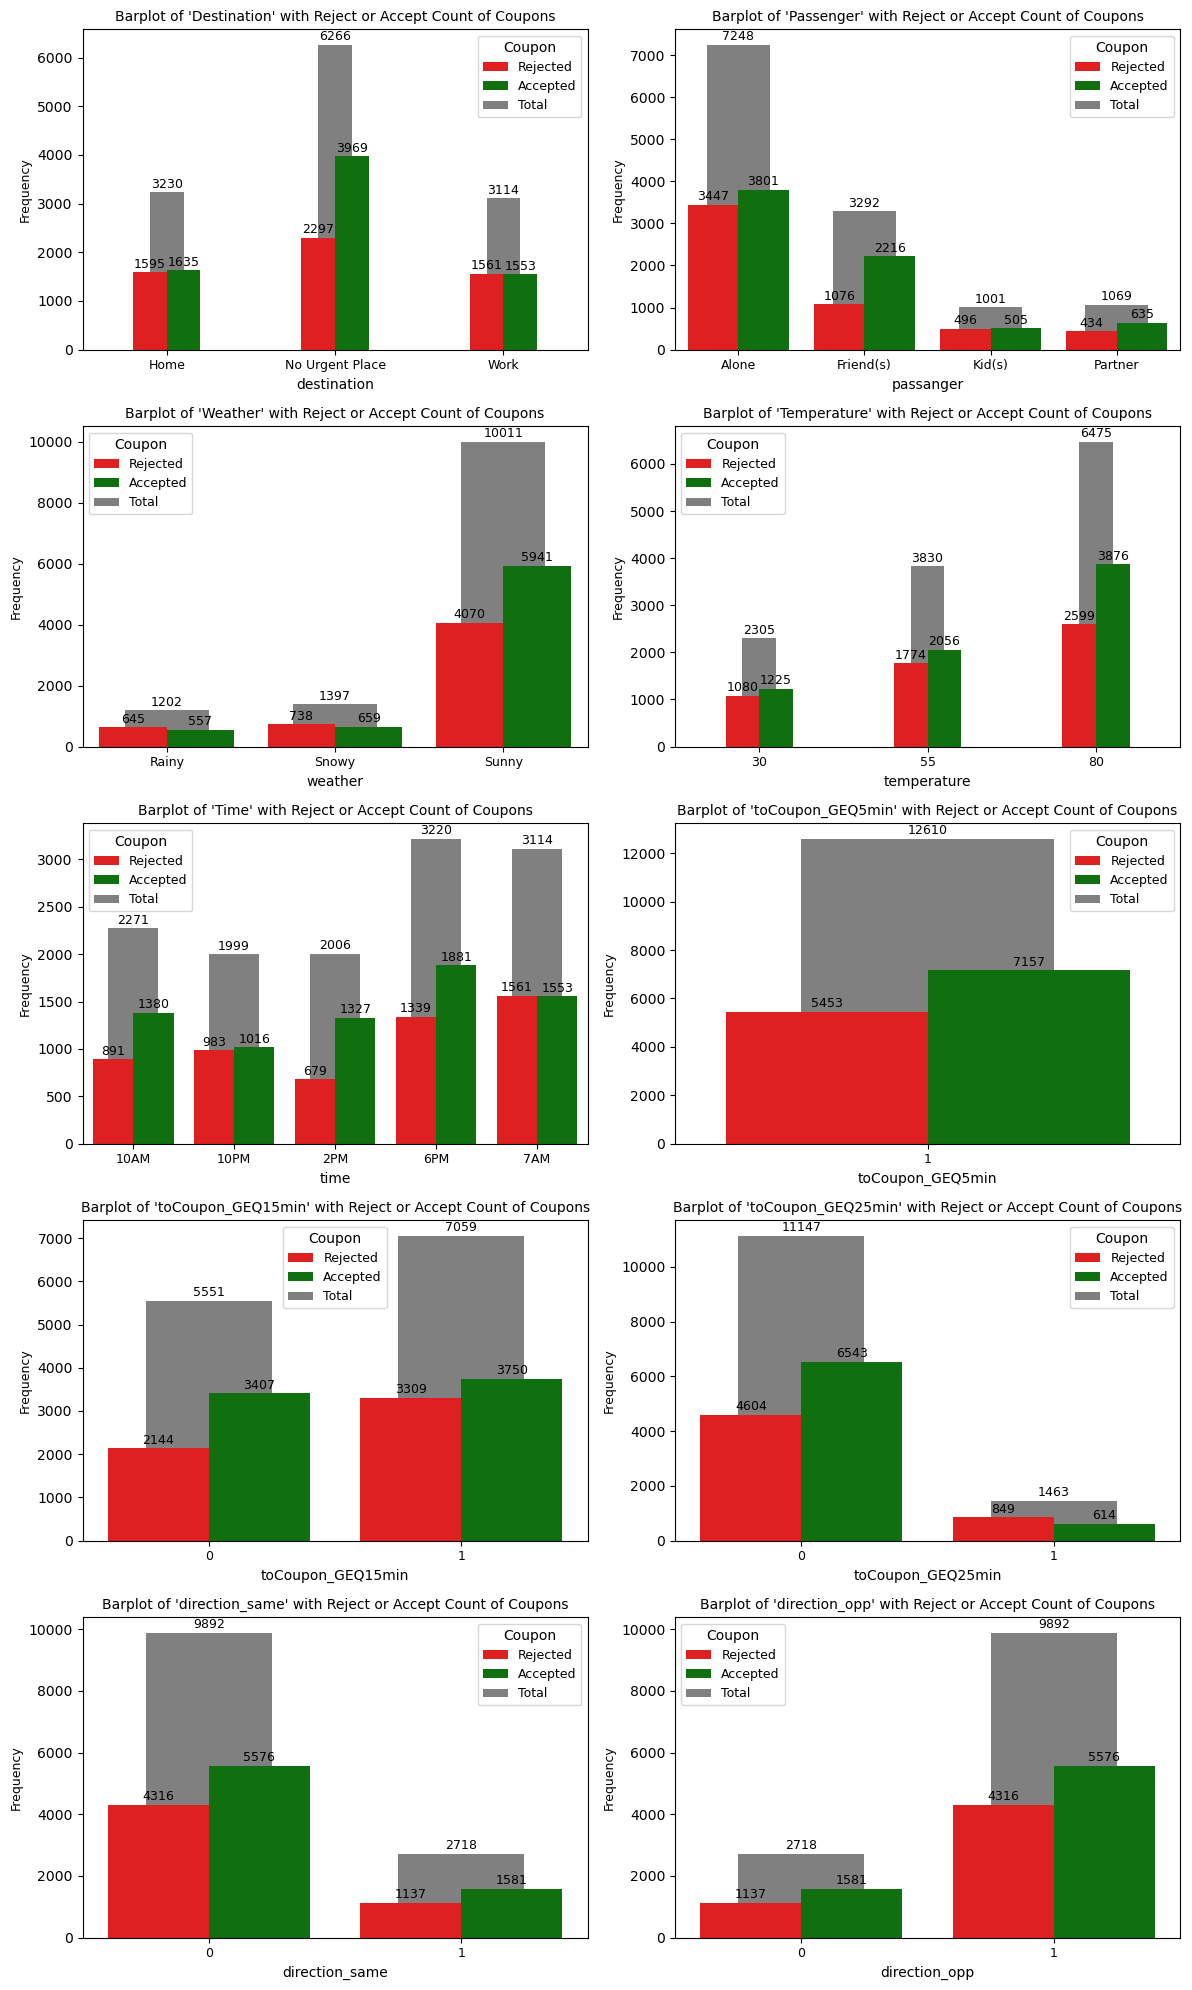

In [16]:
fig, axes = plt.subplots(nrows=5,ncols=2, figsize=(12, 20))

data1.destination.value_counts().sort_index().plot(kind='bar', color='grey',width = 0.2,ax = axes[0,0])
nobs=data1.groupby('destination')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='destination', y='count', hue='Y', palette=custom_palette,width = 0.4, ax = axes[0,0])
ax.set_title("Barplot of 'Destination' with Reject or Accept Count of Coupons", fontsize=10)

data1.passanger.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[0,1])
nobs=data1.groupby('passanger')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='passanger', y='count', hue='Y', palette=custom_palette, ax = axes[0,1])
ax.set_title("Barplot of 'Passenger' with Reject or Accept Count of Coupons", fontsize=10)

data1.weather.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[1,0])
nobs=data1.groupby('weather')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='weather', y='count', hue='Y', palette=custom_palette, ax = axes[1,0])
ax.set_title("Barplot of 'Weather' with Reject or Accept Count of Coupons", fontsize=10)

data1.temperature.value_counts().sort_index().plot(kind='bar', color='grey',width = 0.2,ax = axes[1,1])
nobs=data1.groupby('temperature')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='temperature', y='count', hue='Y', palette=custom_palette,width = 0.4, ax = axes[1,1])
ax.set_title("Barplot of 'Temperature' with Reject or Accept Count of Coupons", fontsize=10)

data1.time.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[2,0])
nobs=data1.groupby('time')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='time', y='count', hue='Y', palette=custom_palette, ax = axes[2,0])
ax.set_title("Barplot of 'Time' with Reject or Accept Count of Coupons", fontsize=10)

data1.toCoupon_GEQ5min.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[2,1])
nobs=data1.groupby('toCoupon_GEQ5min')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='toCoupon_GEQ5min', y='count', hue='Y', palette=custom_palette, ax = axes[2,1])
ax.set_title("Barplot of 'toCoupon_GEQ5min' with Reject or Accept Count of Coupons", fontsize=10)

data1.toCoupon_GEQ15min.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[3,0])
nobs=data1.groupby('toCoupon_GEQ15min')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='toCoupon_GEQ15min', y='count', hue='Y', palette=custom_palette, ax = axes[3,0])
ax.set_title("Barplot of 'toCoupon_GEQ15min' with Reject or Accept Count of Coupons", fontsize=10)

data1.toCoupon_GEQ25min.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[3,1])
nobs=data1.groupby('toCoupon_GEQ25min')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='toCoupon_GEQ25min', y='count', hue='Y', palette=custom_palette, ax = axes[3,1])
ax.set_title("Barplot of 'toCoupon_GEQ25min' with Reject or Accept Count of Coupons", fontsize=10)

data1.direction_same.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[4,0])
nobs=data1.groupby('direction_same')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='direction_same', y='count', hue='Y', palette=custom_palette, ax = axes[4,0])
ax.set_title("Barplot of 'direction_same' with Reject or Accept Count of Coupons", fontsize=10)

data1.direction_opp.value_counts().sort_index().plot(kind='bar', color='grey', ax = axes[4,1])
nobs=data1.groupby('direction_opp')['Y'].value_counts().sort_index().reset_index()
ax = sns.barplot(data=nobs, x='direction_opp', y='count', hue='Y', palette=custom_palette, ax = axes[4,1])
ax.set_title("Barplot of 'direction_opp' with Reject or Accept Count of Coupons", fontsize=10)

for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=0, labelsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['Rejected', 'Accepted', 'Total'], title="Coupon", fontsize=9)
    for container in ax.containers:
        ax.bar_label(container, fontsize=9, padding=1)

plt.tight_layout()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


(2010, 25)
coupon
False    10600
True      2010
Name: count, dtype: int64

 Bar        1~3       4~8       gt8      less1      never
Y                                                       
0     6.965174  1.641791  0.646766  15.572139  34.179104
1    12.786070  5.820896  1.791045  12.437811   8.159204


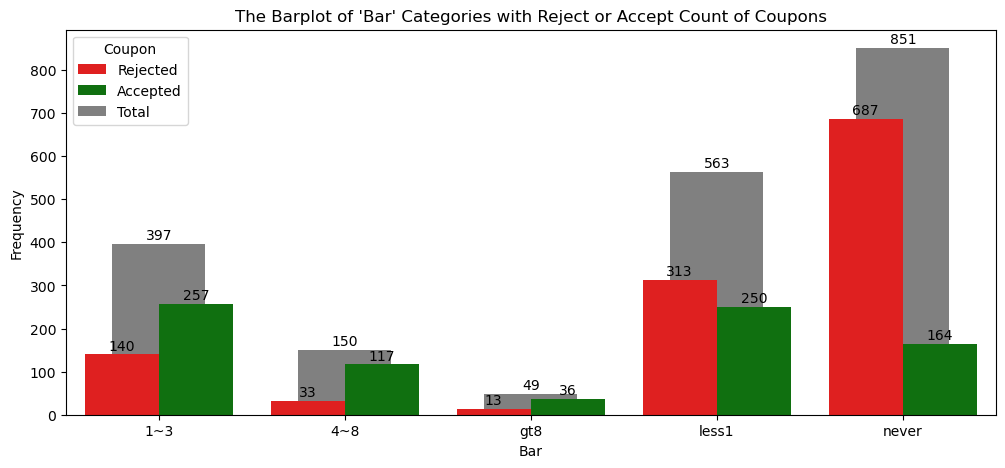

In [17]:
bar_coupons=data1[data1['coupon']=='Bar']
print(bar_coupons.shape)
print((data1['coupon']=='Bar').value_counts())
print('\n',pd.crosstab([bar_coupons['Y']], bar_coupons['Bar'], normalize =True)*100)

fig, axes = plt.subplots(nrows=1,ncols=1, figsize=(12, 5))

bar_coupons.Bar.value_counts().sort_index().plot(kind='bar', color='grey',width = 0.5)
#ax1.bar_label(containers[0], fontsize=10, padding=1)
nobs=bar_coupons.groupby('Bar')['Y'].value_counts().sort_index().reset_index()
ax=sns.barplot(data=nobs, x='Bar', y='count', hue='Y', palette=custom_palette)
ax.set_title("The Barplot of 'Bar' Categories with Reject or Accept Count of Coupons")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Rejected', 'Accepted', 'Total'], title="Coupon")
ax.set_ylabel('Frequency', fontsize=10)
ax.tick_params(axis='x', rotation=0, labelsize=10)
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=1)

plt.show()

2. What proportion of bar coupons were accepted?


In [18]:
print(f"Percentage of bar coupons accepted: {bar_coupons.Y.value_counts()[1]/bar_coupons.shape[0]*100:.1f}%")
bar_coupons.Y.value_counts() #(normalize=True)[1]


Percentage of bar coupons accepted: 41.0%


Y
0    1186
1     824
Name: count, dtype: int64

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [19]:
Bar_3orless = bar_coupons.query('Bar == "never" or Bar == "less1" or Bar == "1~3"')
Bar_moreThan3 = bar_coupons.query('Bar == "gt8" or Bar == "4~8"')

print('\n',pd.crosstab([Bar_3orless['Y']], Bar_3orless['Bar'], normalize =True)*100)
print('\n',pd.crosstab([Bar_moreThan3['Y']], Bar_moreThan3['Bar'], normalize =True)*100)

print(f"\nCoupon acceptance rate for drivers in the category of going to bar 3 or fewer times a month is {(Bar_3orless[['Y']].mean().iloc[0])*100:.1f}%")
print(f"However, the acceptance rate for drivers in the category of going to bar more than 3 times a month is higher: {Bar_moreThan3[['Y']].mean().iloc[0]*100:.1f}%")



 Bar        1~3      less1      never
Y                                   
0     7.730536  17.283269  37.934843
1    14.191055  13.804528   9.055770

 Bar        4~8        gt8
Y                        
0    16.582915   6.532663
1    58.793970  18.090452

Coupon acceptance rate for drivers in the category of going to bar 3 or fewer times a month is 37.1%
However, the acceptance rate for drivers in the category of going to bar more than 3 times a month is higher: 76.9%


BarTwoGroups   Y
Bar_3orless    0    0.629486
               1    0.370514
Bar_moreThan3  1    0.768844
               0    0.231156
Name: proportion, dtype: float64


/var/folders/9f/n01h6dvx1z13fdfthpd1yhnm0000gn/T/ipykernel_51220/2028576961.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_coupons['BarTwoGroups'] = bar_coupons.apply(lambda row: 'Bar_3orless' if row['Bar'] == 'never' or row['Bar'] == 'less1' \


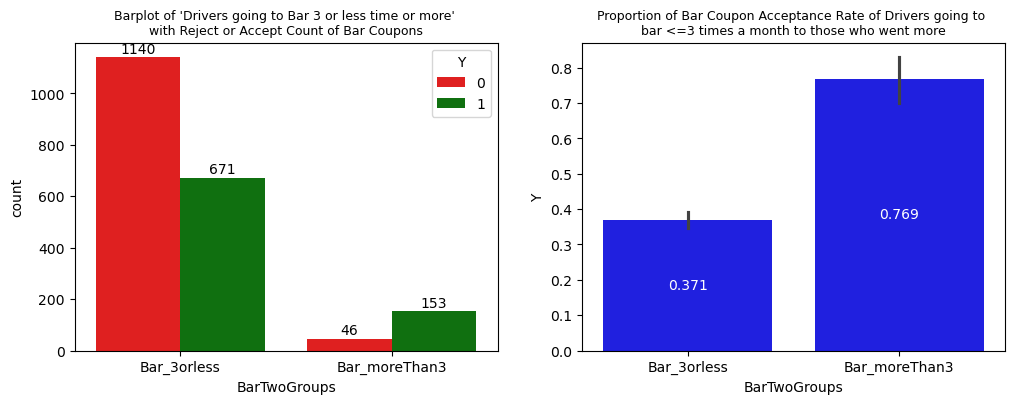

In [20]:
bar_coupons['BarTwoGroups'] = bar_coupons.apply(lambda row: 'Bar_3orless' if row['Bar'] == 'never' or row['Bar'] == 'less1' \
                                                or row['Bar'] == '1~3' else 'Bar_moreThan3', axis=1)
print(bar_coupons.groupby('BarTwoGroups')[['Y']].value_counts(normalize=True))

fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))
ax=sns.barplot(data=bar_coupons, x='BarTwoGroups', y='Y', estimator="mean", color='blue')
for container in ax.containers:
    ax.bar_label(container, label_type='center',color='white',fmt='%.3f')
plt.title('Proportion of Bar Coupon Acceptance Rate of Drivers going to \nbar <=3 times a month to those who went more',\
          color='black', fontsize=9) 

ax=sns.countplot(bar_coupons,x='BarTwoGroups',hue='Y', palette=custom_palette, ax = axes[0])
ax.set_title("Barplot of 'Drivers going to Bar 3 or less time or more' \nwith Reject or Accept Count of Bar Coupons", fontsize=9)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=1)
#bar_coupons[['Bar','BarTwoGroups', 'Y']].sample(10)

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [21]:
age_over25 = ['46', '26', '31', '41', '50plus', '36']
Bar_more_than_once = ['1~3', 'gt8', '4~8']
Bar_moreThan1_ageOver25 = bar_coupons.query('Bar in @Bar_more_than_once and age in @age_over25')
Bar_Acceptance_Rate = Bar_moreThan1_ageOver25[['Y']].mean().iloc[0]*100
print(f"    Acceptance rate for drivers that went to bar more than \
once a month and are over 25: {(Bar_moreThan1_ageOver25[['Y']].mean().iloc[0])*100:.1f}%")
print(f"""
    Yes, the bar coupon acceptance rate is {Bar_Acceptance_Rate:.1f}% for these drivers compared to the all others.""")
#sns.countplot(Bar_moreThan1_ageOver25,x='Bar',hue='Y')
#ax=sns.countplot(bar_coupons,x='BarTwoGroups',hue='Y', palette=custom_palette, ax = axes[0])

    Acceptance rate for drivers that went to bar more than once a month and are over 25: 69.5%

    Yes, the bar coupon acceptance rate is 69.5% for these drivers compared to the all others.


Bar_moreThan1_OverAge25  Y
Bar<=1_Below25           0    0.665409
                         1    0.334591
Bar>1_Above25            1    0.695238
                         0    0.304762
Name: proportion, dtype: float64


/var/folders/9f/n01h6dvx1z13fdfthpd1yhnm0000gn/T/ipykernel_51220/2449462718.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_coupons['Bar_moreThan1_OverAge25']= bar_coupons.apply(lambda row: 'Bar<=1_Below25' if (row['Bar'] == 'never' or row['Bar'] == 'less1') \


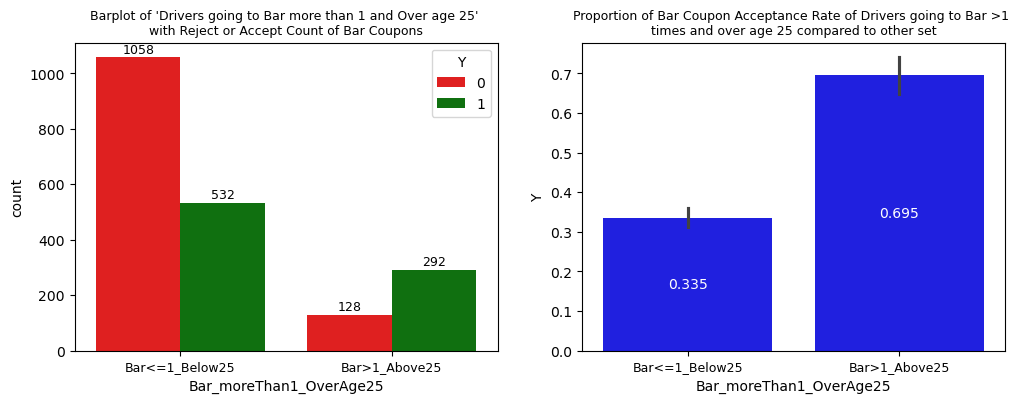

In [22]:

bar_coupons['Bar_moreThan1_OverAge25']= bar_coupons.apply(lambda row: 'Bar<=1_Below25' if (row['Bar'] == 'never' or row['Bar'] == 'less1') \
                                                or (row['age'] == 'below21' or row['age'] == '21') else 'Bar>1_Above25', axis=1)
print(bar_coupons.groupby('Bar_moreThan1_OverAge25')[['Y']].value_counts(normalize=True))

fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))
ax=sns.barplot(data=bar_coupons, x='Bar_moreThan1_OverAge25', y='Y', estimator="mean", color='blue')
for container in ax.containers:
    ax.bar_label(container, label_type='center',color='white',fmt='%.3f')
plt.title('Proportion of Bar Coupon Acceptance Rate of Drivers going to Bar >1 \ntimes and over age 25 compared to other set',\
           fontsize=9) 

ax=sns.countplot(bar_coupons,x='Bar_moreThan1_OverAge25',hue='Y', palette=custom_palette, ax = axes[0])
ax.set_title("Barplot of 'Drivers going to Bar more than 1 and Over age 25' \nwith Reject or Accept Count of Bar Coupons", fontsize=9)
for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=1)
for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=0, labelsize=9)


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [23]:
occupation_category = ['Farming Fishing & Forestry']
passanger_category = ['Kid(s)']
Bar_moreThan1_NoKid_NoFFF = bar_coupons.query(
    'Bar in @Bar_more_than_once and passanger not in @passanger_category and occupation not in @occupation_category')
Bar_Acceptance_Rate5 = Bar_moreThan1_NoKid_NoFFF[['Y']].mean().iloc[0]*100
print(f"""
    Acceptance rate for those that went to bar more than once a month and do not have kid as 
    passenger and do not have occupation as farming, fishing and forestry: {Bar_Acceptance_Rate5:.1f}%    """)

print(f"""
    The bar coupon acceptance rate is {Bar_Acceptance_Rate5:.1f}% for these drivers
    compared to {100-Bar_Acceptance_Rate5:.1f}% for those that never go to bar and 
    have kid as passanger and have occupation as farming, fishing and forestry.    """)


    Acceptance rate for those that went to bar more than once a month and do not have kid as 
    passenger and do not have occupation as farming, fishing and forestry: 71.3%    

    The bar coupon acceptance rate is 71.3% for these drivers
    compared to 28.7% for those that never go to bar and 
    have kid as passanger and have occupation as farming, fishing and forestry.    


Bar>1_NoKid_NoFarm          Y
BarLess1_wKid_Farm          0    0.704592
                            1    0.295408
BarMoreThan1_w/oKid_NoFarm  1    0.713249
                            0    0.286751
Name: proportion, dtype: float64


/var/folders/9f/n01h6dvx1z13fdfthpd1yhnm0000gn/T/ipykernel_51220/3839939720.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_coupons['Bar>1_NoKid_NoFarm']= bar_coupons.apply(lambda row: 'BarLess1_wKid_Farm' if (row['Bar'] == 'never' or row['Bar'] == 'less1') \


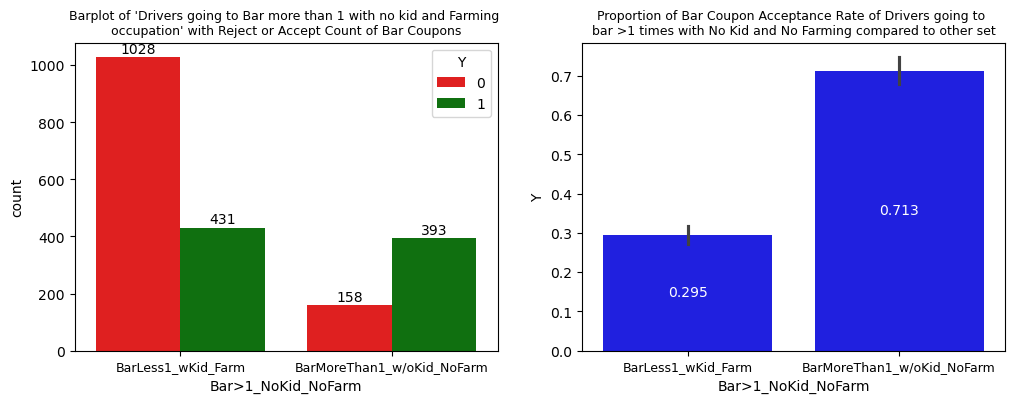

In [24]:
bar_coupons['Bar>1_NoKid_NoFarm']= bar_coupons.apply(lambda row: 'BarLess1_wKid_Farm' if (row['Bar'] == 'never' or row['Bar'] == 'less1') \
                    or (row['passanger'] == 'Kid(s)' or row['occupation'] == 'Farming Fishing & Forestry') else 'BarMoreThan1_w/oKid_NoFarm', axis=1)
print(bar_coupons.groupby('Bar>1_NoKid_NoFarm')[['Y']].value_counts(normalize=True))

fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))
ax=sns.barplot(data=bar_coupons, x='Bar>1_NoKid_NoFarm', y='Y', estimator="mean", color='blue')
for container in ax.containers:
    ax.bar_label(container, label_type='center',color='white',fmt='%.3f')
plt.title('Proportion of Bar Coupon Acceptance Rate of Drivers going to \nbar >1 times with No Kid and No Farming compared to other set',\
          fontsize=9) 

ax=sns.countplot(bar_coupons,x='Bar>1_NoKid_NoFarm',hue='Y', palette=custom_palette, ax = axes[0])
ax.set_title("Barplot of 'Drivers going to Bar more than 1 with no kid and Farming \noccupation' with Reject or Accept Count of Bar Coupons",\
             fontsize=9)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=1)
for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=0, labelsize=9)


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [25]:
maritalStatus_category = ['Widowed']
Bar_moreThan1_NoKid_NotWidow = bar_coupons.query('Bar in @Bar_more_than_once and \
passanger not in @passanger_category and maritalStatus not in @maritalStatus_category')
Bar_Acceptance_Rate6_1 = Bar_moreThan1_NoKid_NotWidow[['Y']].mean().iloc[0]*100
print(f"""
    Acceptance rate for those that went to bar more than once a month and do not have kid as 
    passenger and were not widowed: {Bar_Acceptance_Rate6_1:.1f}%    """)

age_category = ['below21', '21', '26']
Bar_moreThan1_Below30age = bar_coupons.query('Bar in @Bar_more_than_once and age in @age_category')
Bar_Acceptance_Rate6_2 = Bar_moreThan1_Below30age[['Y']].mean().iloc[0]*100
print(f"""
    Acceptance rate for those that went to bar more than once a month and are under 30 age : {Bar_Acceptance_Rate6_2:.1f}%    """)

income_category = ['$37500 - $49999']
RestaurantLessThan20_category = ['4~8', 'gt8']
BarCoupon_CheapRestaurant_IncomeBelow50K = bar_coupons.query('income in @income_category \
and RestaurantLessThan20 in @RestaurantLessThan20_category')
Bar_Acceptance_Rate6_3 = BarCoupon_CheapRestaurant_IncomeBelow50K[['Y']].mean().iloc[0]*100
print(f"""
    Acceptance rate for those that go to cheap restaurant more than 4 times a month and earn below 50K : {Bar_Acceptance_Rate6_3:.1f}%    """)



    Acceptance rate for those that went to bar more than once a month and do not have kid as 
    passenger and were not widowed: 71.3%    

    Acceptance rate for those that went to bar more than once a month and are under 30 age : 72.2%    

    Acceptance rate for those that go to cheap restaurant more than 4 times a month and earn below 50K : 49.0%    


Bar>1_Below30age     Y
BarLessThan1Above30  0    0.654655
                     1    0.345345
BarMoreThan1Below30  1    0.721739
                     0    0.278261
Name: proportion, dtype: float64


/var/folders/9f/n01h6dvx1z13fdfthpd1yhnm0000gn/T/ipykernel_51220/1264647609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_coupons['Bar>1_Below30age']= bar_coupons.apply(lambda row: 'BarMoreThan1Below30' if (row['Bar'] == '1~3' or row['Bar'] == '4~8'  \


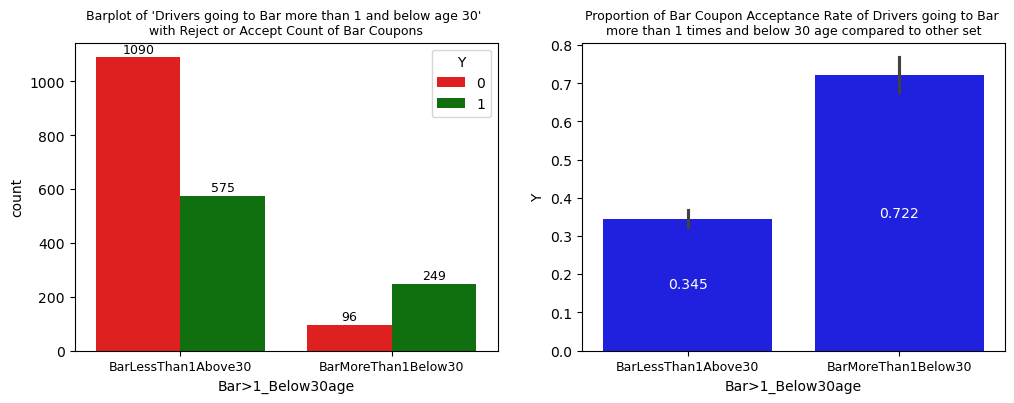

In [26]:
bar_coupons['Bar>1_Below30age']= bar_coupons.apply(lambda row: 'BarMoreThan1Below30' if (row['Bar'] == '1~3' or row['Bar'] == '4~8'  \
                    or row['Bar'] == 'gt8') and (row['age'] == '26' or row['age'] == 'below21'or row['age'] == '21') else 'BarLessThan1Above30', axis=1)
print(bar_coupons.groupby('Bar>1_Below30age')[['Y']].value_counts(normalize=True))

fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))
ax=sns.barplot(data=bar_coupons, x='Bar>1_Below30age', y='Y', estimator="mean", color='blue')
for container in ax.containers:
    ax.bar_label(container, label_type='center',color='white',fmt='%.3f')
plt.title('Proportion of Bar Coupon Acceptance Rate of Drivers going to Bar \nmore than 1 times and below 30 age compared to other set', fontsize=9) 

ax=sns.countplot(bar_coupons,x='Bar>1_Below30age',hue='Y', palette=custom_palette, ax = axes[0])
ax.set_title("Barplot of 'Drivers going to Bar more than 1 and below age 30' \nwith Reject or Accept Count of Bar Coupons",\
             fontsize=9)

for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=1)
for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=0, labelsize=9)


CheapRest_50kIncome              Y
CheapRest<4times_IncomeAbove50K  0    0.594142
                                 1    0.405858
CheapRest>4times_IncomeBelow50K  0    0.510204
                                 1    0.489796
Name: proportion, dtype: float64


/var/folders/9f/n01h6dvx1z13fdfthpd1yhnm0000gn/T/ipykernel_51220/2086819261.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_coupons['CheapRest_50kIncome']= bar_coupons.apply(lambda row: 'CheapRest>4times_IncomeBelow50K' if row['income'] == '$37500 - $49999'  \


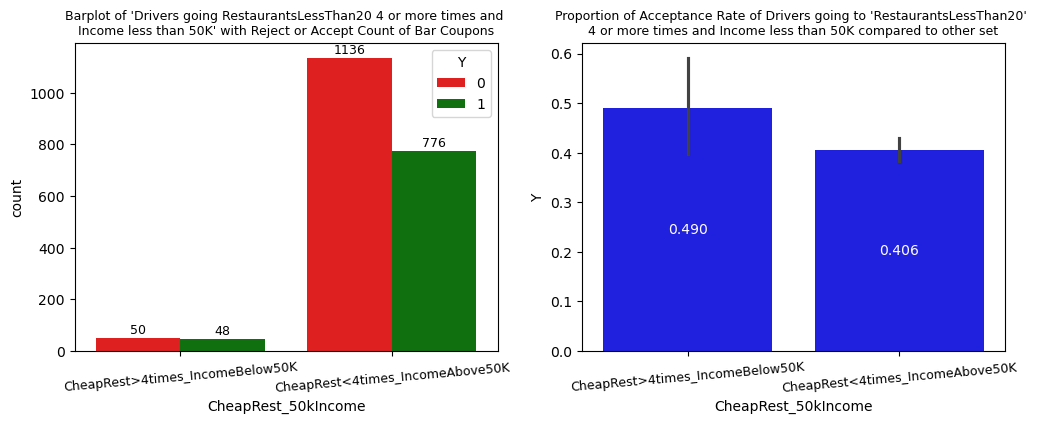

In [27]:
bar_coupons['CheapRest_50kIncome']= bar_coupons.apply(lambda row: 'CheapRest>4times_IncomeBelow50K' if row['income'] == '$37500 - $49999'  \
                    and (row['RestaurantLessThan20'] == '4~8' or row['RestaurantLessThan20'] == 'gt8') else 'CheapRest<4times_IncomeAbove50K', axis=1)
print(bar_coupons.groupby('CheapRest_50kIncome')[['Y']].value_counts(normalize=True))

fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))
ax=sns.barplot(data=bar_coupons, x='CheapRest_50kIncome', y='Y', estimator="mean", color='blue')
for container in ax.containers:
    ax.bar_label(container, label_type='center',color='white',fmt='%.3f')
plt.title("Proportion of Acceptance Rate of Drivers going to 'RestaurantsLessThan20' \n4 or more times and Income less than 50K compared to other set", fontsize=9) 

ax=sns.countplot(bar_coupons,x='CheapRest_50kIncome',hue='Y', palette=custom_palette, ax = axes[0])
ax.set_title("Barplot of 'Drivers going RestaurantsLessThan20 4 or more times and \nIncome less than 50K' with Reject or Accept Count of Bar Coupons",\
             fontsize=9)

for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=1)
for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=5, labelsize=9)


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Since the count of all observation of 

Since the count of drivers of all scenarios of coupons sent to bar are greater than 30, therefore Central Limit Theorem of statistics, we can assume that the sampling distribution of the mean will be approximately normal.

Based on CLT and the data analysis, we can hypothesize that ~41% or slightly less than average drivers accepted bar coupons.  The attributes of the drivers accepting coupons are :
* likely go to bar more than 3 times (77% acceptance rate)
* The one that go to bar more than once and are mostly over 25 age(~70% acceptance rate). However since the acceptance rate of below 30 age is also at the similar range (72.2%), it is hypothesized that drivers are going to bar at the similar frequency once they get over 21 age.
* have no kid as passanger and do not have as farming, fishing and forestry (71.3% acceptance rate)
* going to cheap restaurant more than 4 times a month and earn below 50K is not a significant factor common to most drivers acceptance rate (49%)

Based on this we can hypothesize that about if a driver accepts bar coupon they go to bar more than 3 times.

In [28]:
bar_coupons['Bar>1_26age']= bar_coupons.apply(lambda row: True if (row['Bar'] == '1~3' or row['Bar'] == '4~8'  \
                    or row['Bar'] == 'gt8') and (row['age'] == '21' ) else False, axis=1)
print(bar_coupons.groupby('Bar>1_26age')[['Y']].value_counts(normalize=True))


Bar>1_26age  Y
False        0    0.614967
             1    0.385033
True         1    0.686747
             0    0.313253
Name: proportion, dtype: float64


/var/folders/9f/n01h6dvx1z13fdfthpd1yhnm0000gn/T/ipykernel_51220/3992193868.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bar_coupons['Bar>1_26age']= bar_coupons.apply(lambda row: True if (row['Bar'] == '1~3' or row['Bar'] == '4~8'  \


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

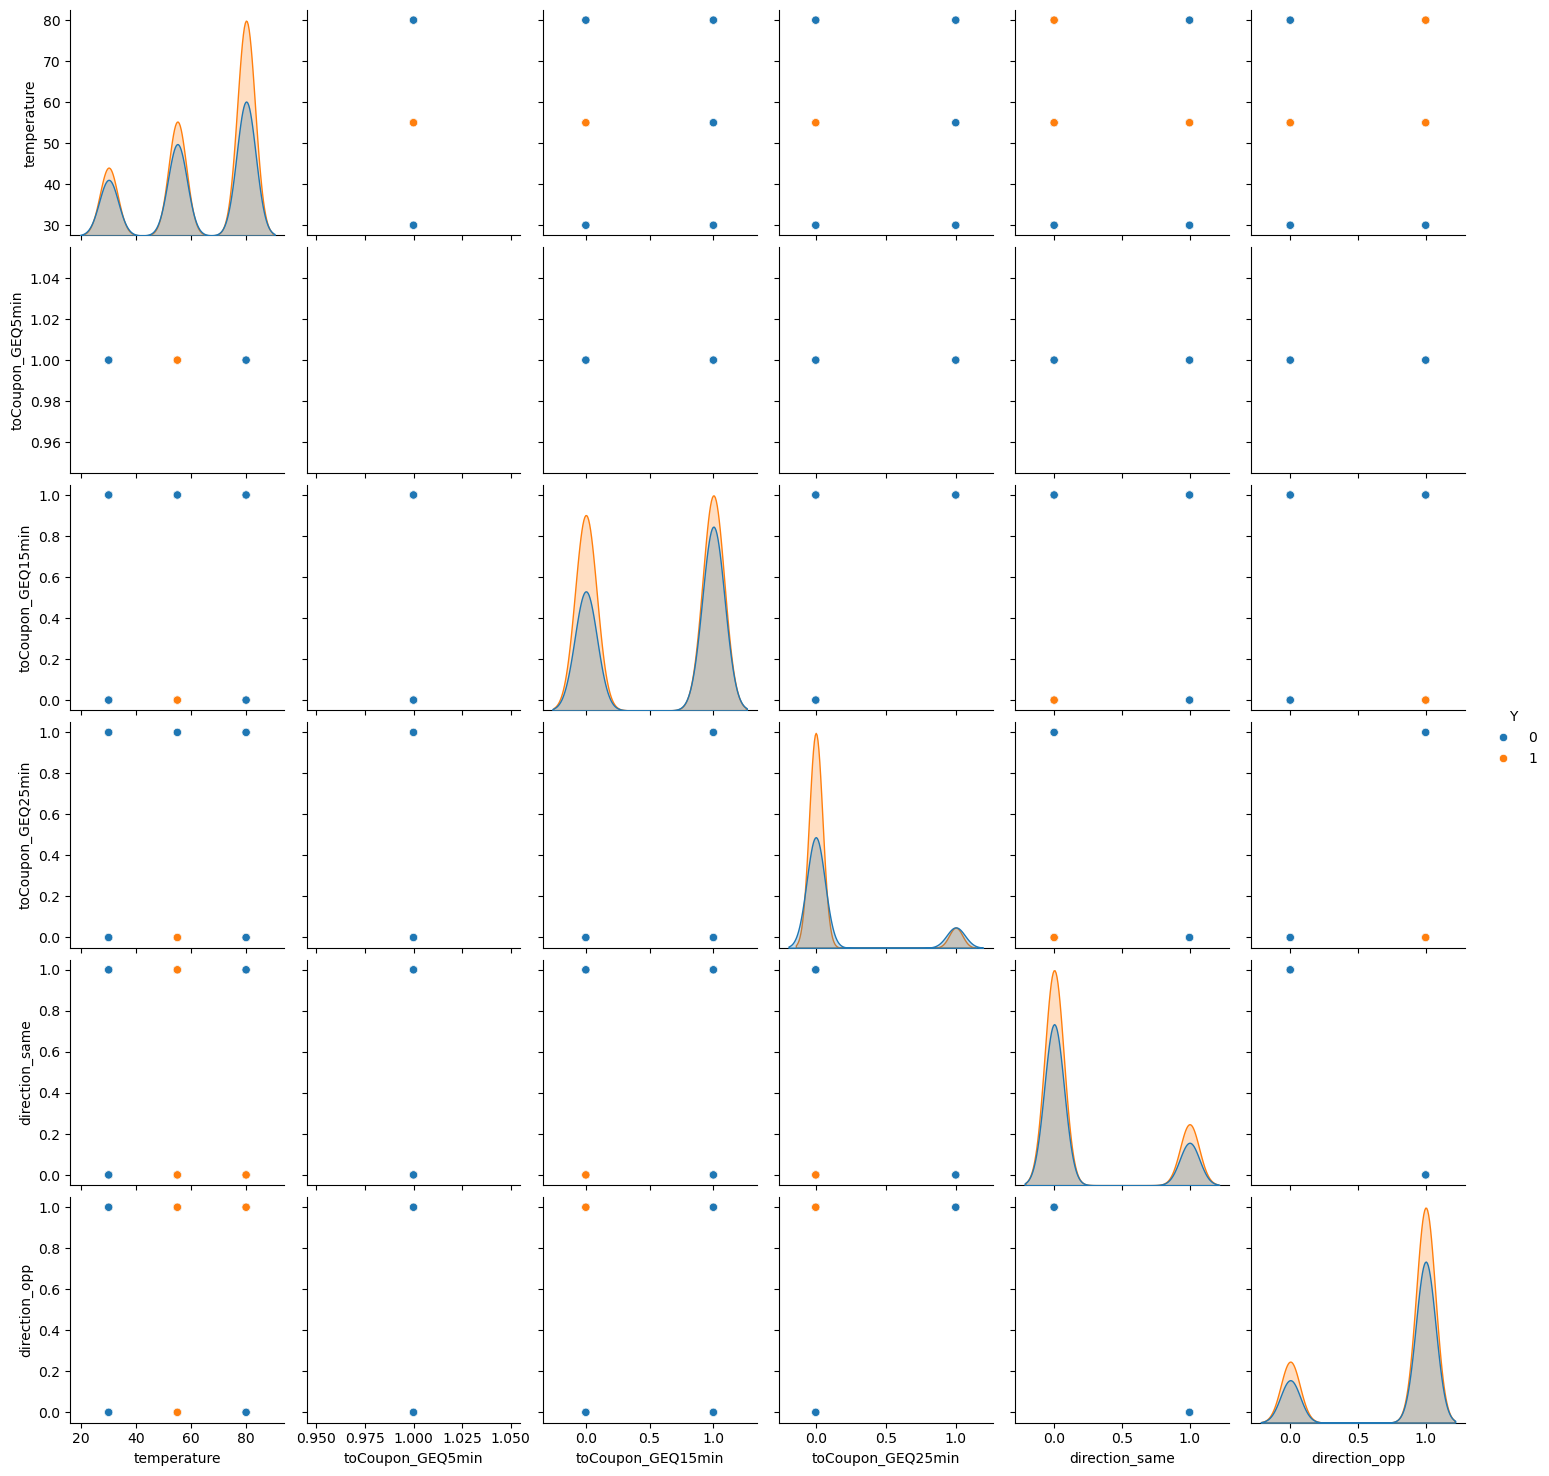

In [901]:
sns.pairplot(data1[['temperature', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min','direction_same', 'direction_opp', 'Y']],\
             hue='Y')

In [29]:
CarryOut_coupons=data1[data1['coupon']=='Carry out & Take away']
print(CarryOut_coupons.shape)
print((data1['coupon']=='CarryOut_coupons').value_counts())
print('\n',pd.crosstab([CarryOut_coupons['Y']], CarryOut_coupons['CarryAway'], normalize =True)*100)
print(f"\nPercentage of CarryAway coupons accepted: {CarryOut_coupons.Y.value_counts()[1]/CarryOut_coupons.shape[0]*100:.1f}%")
CarryOut_coupons.Y.value_counts(normalize=True)


(2344, 25)
coupon
False    12610
Name: count, dtype: int64

 CarryAway        1~3        4~8       gt8     less1     never
Y                                                            
0           9.726962   8.447099  3.327645  4.778157  0.341297
1          27.389078  25.853242  9.172355  9.982935  0.981229

Percentage of CarryAway coupons accepted: 73.4%


Y
1    0.733788
0    0.266212
Name: proportion, dtype: float64

CarryOut_Above40  Y
AgeAbove40        1    0.750000
                  0    0.250000
AgeBelow40        1    0.728889
                  0    0.271111
Name: proportion, dtype: float64

Acceptance rate of CarryOut couopons for those that take Carryout and Above40 are : 75.0%    


/var/folders/9f/n01h6dvx1z13fdfthpd1yhnm0000gn/T/ipykernel_51220/4256277766.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CarryOut_coupons['CarryOut_Above40']= CarryOut_coupons.apply(lambda row: 'AgeAbove40' if (row['age'] == '41'
/var/folders/9f/n01h6dvx1z13fdfthpd1yhnm0000gn/T/ipykernel_51220/4256277766.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Acceptance rate of CarryOut couopons for those that take Carryout and Above40 are : {results[0]*100:.1f}%    """)


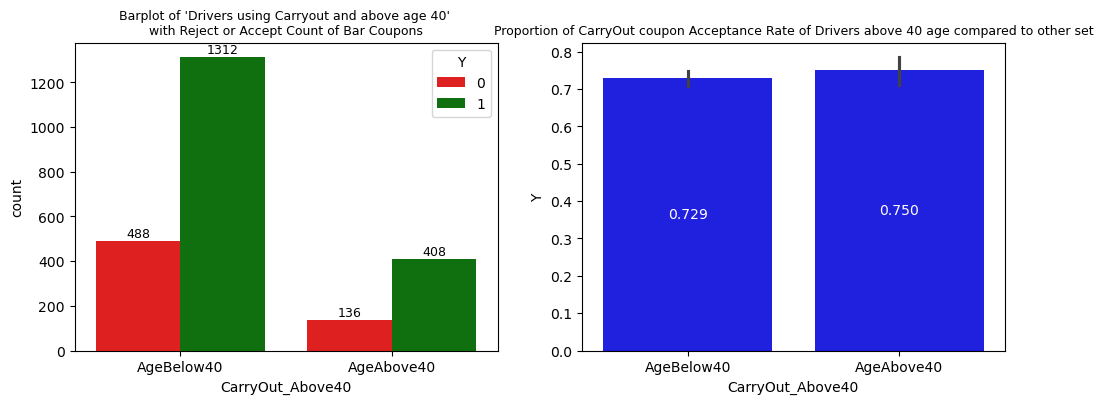

In [41]:
CarryOut_coupons['CarryOut_Above40']= CarryOut_coupons.apply(lambda row: 'AgeAbove40' if (row['age'] == '41' 
                                                                                 or row['age'] == '50plus') 
                                                                                else 'AgeBelow40', axis=1)
                    #or row['Bar'] == 'gt8') and (row['age'] == '26' or row['age'] == 'below21'or row['age'] == '21') else False, axis=1)
results=CarryOut_coupons.groupby('CarryOut_Above40')[['Y']].value_counts(normalize=True)
print(results)

fig, axes = plt.subplots(nrows=1,ncols=2, figsize=(12, 4))
ax=sns.barplot(data=CarryOut_coupons, x='CarryOut_Above40', y='Y', estimator="mean", color='blue')
for container in ax.containers:
    ax.bar_label(container, label_type='center',color='white',fmt='%.3f')
plt.title('Proportion of CarryOut coupon Acceptance Rate of Drivers above 40 age compared to other set', fontsize=9) 

ax=sns.countplot(CarryOut_coupons,x='CarryOut_Above40',hue='Y', palette=custom_palette, ax = axes[0])
ax.set_title("Barplot of 'Drivers using Carryout and above age 40' \nwith Reject or Accept Count of Bar Coupons",\
             fontsize=9)

for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=1)
print(f"""
Acceptance rate of CarryOut couopons for those that take Carryout and Above40 are : {results[0]*100:.1f}%    """)
